In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, XGBRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
pd.options.display.float_format = '{:.4f}'.format
%matplotlib inline

# 데이터 로드
df = pd.read_csv('../data/processed/refined_data.csv')
print(f"데이터 크기: {df.shape}")

데이터 크기: (44868, 11)


--- [다중 선형 회귀 결과] ---
문장_길이 계수: -0.0004
단어_평균길이 계수: -0.0182
어휘_다양성 계수: -1.3917
단어_밀도 계수: -22.8080
특문_개수 계수: 0.0113
R-squared: 0.4469


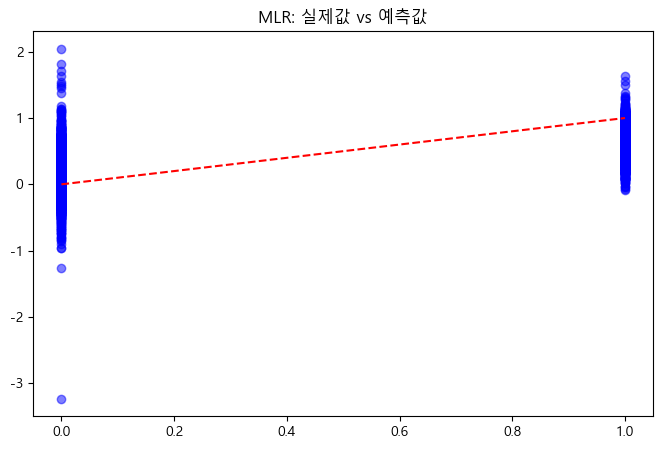

In [48]:
'''
다중 선형 회귀 
다중공선성 고려 해서 '단어_개수' 제외 vif 값이 너무 높음
단어밀도는 유의미하게 영향을 미치지만 r2_score 값이 낮음
'''
# 피처 선택 
features = ['문장_길이', '단어_평균길이', '어휘_다양성', '단어_밀도', '특문_개수']
X_num = df[features]
y = df['라벨']

X_train, X_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42)

# 모델 학습
mlr_model = LinearRegression()
mlr_model.fit(X_train, y_train)
y_pred_mlr = mlr_model.predict(X_test)

# 결과 출력
print("--- [다중 선형 회귀 결과] ---")
for feature, coef in zip(features, mlr_model.coef_):
    print(f"{feature} 계수: {coef:.4f}")
print(f"R-squared: {r2_score(y_test, y_pred_mlr):.4f}")

# 시각화: 실제값 vs 예측값
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_mlr, color='blue', alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--')
plt.title('MLR: 실제값 vs 예측값')
plt.show()

In [49]:
'''
나이브 베이즈 모델
불용어 제거된 문장으로 벡터화 후 모델 학습 -> 학습할때는 불용어 제거 처리 해야함
단어의 빈도(tf) - 얼마나 자주 나오냐
역문서 빈도(idf) - 모든 문장에 다 나오는 흔한단어인가 ? 희소성개념? 
이 두가지 개념을 이용해서 단어에 점수를 매긴다
'''

# TFIDF 벡터화  
# 상위 3000개만 사용하겠다
vectorizer = TfidfVectorizer(stop_words='english', max_features=3000)
X_tfidf = vectorizer.fit_transform(df['불용어_제거'])

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 모델 학습
nb_model = MultinomialNB()
nb_model.fit(X_train_v, y_train_v)
y_pred_nb = nb_model.predict(X_test_v)

print("--- [나이브 베이즈 결과] ---")
print(f"Accuracy: {accuracy_score(y_test_v, y_pred_nb):.4f}")
print(classification_report(y_test_v, y_pred_nb))

joblib.dump(nb_model, 'nb_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print("시연용 모델 저장 완료!")

--- [나이브 베이즈 결과] ---
Accuracy: 0.9515
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      5481
           1       0.97      0.90      0.94      3493

    accuracy                           0.95      8974
   macro avg       0.96      0.94      0.95      8974
weighted avg       0.95      0.95      0.95      8974

시연용 모델 저장 완료!


RF 최적 파라미터: {'max_depth': 10, 'n_estimators': 100}
RF 정확도: 0.8771
RF F1-score: 0.8398


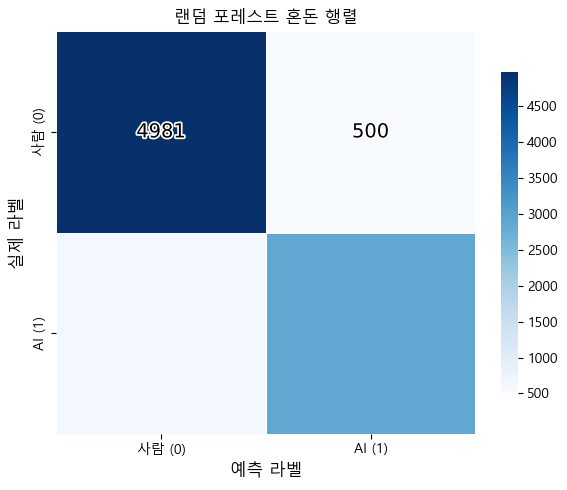

In [50]:
'''
랜덤 포레스트 분석
하이퍼 파라미터
'''


# 그리드 서치 설정
rf_model = RandomForestClassifier(random_state=42)
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [5, 10]}

grid_rf = GridSearchCV(rf_model, param_grid_rf, cv=3, scoring='accuracy')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(f"RF 최적 파라미터: {grid_rf.best_params_}")
print(f"RF 정확도: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"RF F1-score: {f1_score(y_test, y_pred_rf, average='binary'):.4f}")

# 시각화: 혼동 행렬 (행=실제, 열=예측)
# 숫자가 안 보임 = 데이터 문제가 아니라, seaborn이 셀 색에 맞춰 글자색을 고르다가
# 밝은 칸에서 흰색 글자가 선택되는 등 대비가 깨지는 경우가 많음 → 흰 테두리+검정 글자로 고정
import matplotlib.patheffects as pe

cm_rf = confusion_matrix(y_test, y_pred_rf)
labels = ['사람 (0)', 'AI (1)']
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    xticklabels=labels,
    yticklabels=labels,
    annot_kws={'fontsize': 14, 'fontfamily': 'DejaVu Sans', 'color': 'black'},
    cbar_kws={'shrink': 0.8},
    ax=ax,
)
for t in ax.texts:
    t.set_path_effects([pe.withStroke(linewidth=2.5, foreground='white')])
    t.set_color('black')
ax.set_xlabel('예측 라벨', fontsize=12)
ax.set_ylabel('실제 라벨', fontsize=12)
ax.set_title('랜덤 포레스트 혼돈 행렬')
fig.tight_layout()
plt.show()

In [ ]:
# XGBoost 모델 설정 특성중요도
xgb = XGBClassifier(objective='binary:logistic', random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=3, scoring='accuracy', verbose=1)
grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print(f"XGB 최적 파라미터: {grid_xgb.best_params_}")
print(f"XGB 정확도: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"XGB F1-score: {f1_score(y_test, y_pred_xgb, average='binary'):.4f}")

# 시각화: (1) 모델 내장 특성 중요도  (2) 퍼뮤테이션 중요도 — 같은 XGBoost 블록에서 비교
BAR_COLOR = '#3478b5'
BAR_EDGE = '#2a5f8f'

importances = best_xgb.feature_importances_
indices = np.argsort(importances)[::-1]
order_labels = [features[i] for i in indices]
vals = importances[indices]

perm = permutation_importance(
    best_xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1,
)
perm_idx = np.argsort(perm.importances_mean)[::-1]
perm_labels = [features[i] for i in perm_idx]
perm_vals = perm.importances_mean[perm_idx]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(x=vals, y=order_labels, color=BAR_COLOR, edgecolor=BAR_EDGE, linewidth=0.8, ax=ax1)
ax1.set_xlabel('특성 중요도 (gain/분할 기준)', fontsize=11)
ax1.set_ylabel('특성', fontsize=12)
ax1.set_title('XGBoost 내장 특성 중요도')

sns.barplot(x=perm_vals, y=perm_labels, color=BAR_COLOR, edgecolor=BAR_EDGE, linewidth=0.8, ax=ax2)
ax2.set_xlabel('퍼뮤테이션 중요도 (정확도 감소 평균)', fontsize=11)
ax2.set_ylabel('특성', fontsize=12)
ax2.set_title('퍼뮤테이션 중요도')

fig.suptitle('XGBoost: 특성 중요도 비교', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

Fitting 3 folds for each of 8 candidates, totalling 24 fits


In [ ]:
# 가장 성능이 좋은 XGBoost와 벡터라이저 저장
joblib.dump(best_xgb, 'best_xgb_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("모델 저장 완료!")

모델 저장 완료!
